In [1]:
import taichi as ti
ti.init(arch=ti.cpu, default_fp=ti.f64, cpu_max_num_threads=1, offline_cache=False, debug=True)

from pespace.waveform.interface_lalsim import WaveformLALSimulationInterface
from tiwave.waveforms import IMRPhenomXAS

import numpy as np
import lalsimulation as lalsim
import lal
import bilby
from matplotlib import pyplot as plt
%matplotlib inline

[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.10.19
[Taichi] Starting on arch=x64


[I 02/05/26 11:24:03.212 167366] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout
/home/nrui/disk_ext/workspace/pespace/pespace/waveform/interface_lalsim.py:11: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
dt = 1/4096
df = 1/4
fref = 20.0
fmin = 20.0
fmax = 4096.0
appro = "IMRPhenomXAS"

params = dict(
    mass_1=36.0,
    mass_2=29.0,
    luminosity_distance=800.0,
    reference_phase=1.2,
    chi_1=-0.4,
    chi_2=0.02,
    inclination=0.4,
)


In [3]:
wf_pespace_TD = WaveformLALSimulationInterface(
    domain='td',
    approximant=appro,
    sampling_interval=dt,
    reference_frequency=fref,
    minimum_frequency=fmin,
    maximum_frequency=fmax,
    parameter_conversion=bilby.gw.conversion.generate_component_spins
)
wf_pespace_TD.update_waveform(params)

In [4]:
appro_lal = lalsim.GetApproximantFromString(appro)
extra_params_lal = lal.CreateDict()
hp_lal_TD, hc_lal_TD = lalsim.SimInspiralChooseTDWaveform(
    float(params["mass_1"] * lal.MSUN_SI),
    float(params["mass_2"] * lal.MSUN_SI),
    float(0.0),
    float(0.0),
    float(params["chi_1"]),
    float(0.0),
    float(0.0),
    float(params["chi_2"]),
    float(params["luminosity_distance"] * 1e6 * lal.PC_SI),
    float(params["inclination"]),
    float(params["reference_phase"]),
    float(0.0),
    float(0.0),
    float(0.0),
    float(dt),
    float(fmin),
    float(fref),
    extra_params_lal,
    appro_lal,
)


hp_lal_TD epoch:  -1.889160156
pespace waveform_container t0:  -1.889160156
0.0
0.0


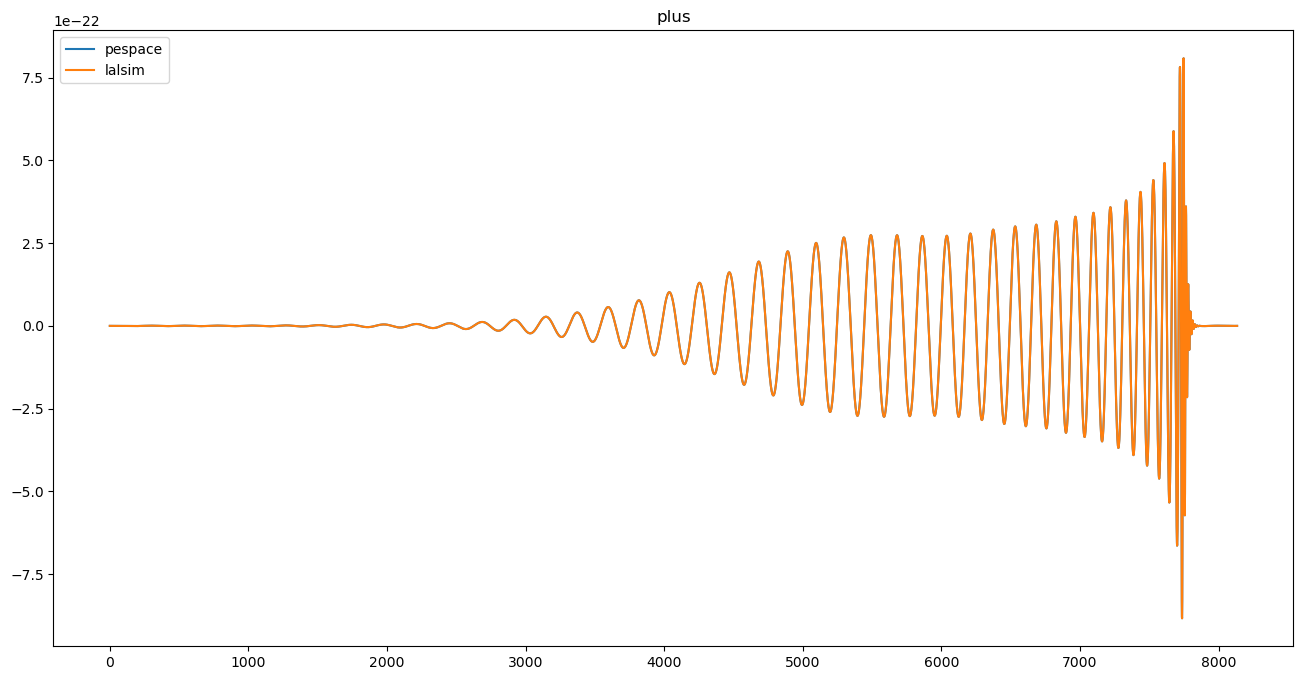

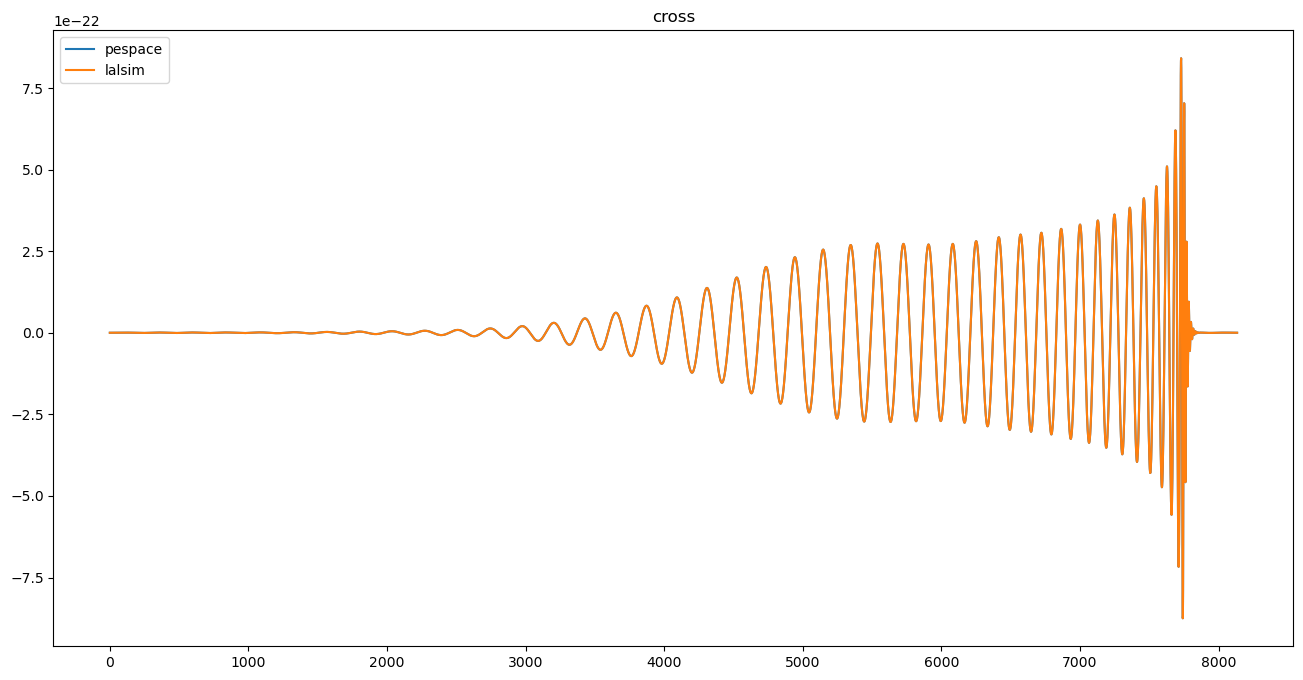

In [5]:
print("hp_lal_TD epoch: ", float(hp_lal_TD.epoch))
print("pespace waveform_container t0: ", wf_pespace_TD.waveform_container["t0"])

diff_hp = np.abs(wf_pespace_TD.waveform_container["data"][:,0] - hp_lal_TD.data.data)
diff_hc = np.abs(wf_pespace_TD.waveform_container["data"][:,1] - hc_lal_TD.data.data)
print(diff_hp.max())
print(diff_hc.max())

plt.figure(figsize=[16, 8])
plt.title('plus')
plt.plot(wf_pespace_TD.waveform_container["data"][:,0], label="pespace")
plt.plot(hp_lal_TD.data.data, label='lalsim')
plt.legend()

plt.figure(figsize=[16, 8])
plt.title('cross')
plt.plot(wf_pespace_TD.waveform_container["data"][:,1], label="pespace")
plt.plot(hc_lal_TD.data.data, label='lalsim')
plt.legend()


In [6]:
wf_pespace_FD = WaveformLALSimulationInterface(
    domain='fd',
    approximant='IMRPhenomXAS',
    sampling_interval=df,
    reference_frequency=fref,
    minimum_frequency=fmin,
    maximum_frequency=fmax,
    parameter_conversion=bilby.gw.conversion.generate_component_spins
)
wf_pespace_FD.update_waveform(params)

In [7]:
wf_tiwave = IMRPhenomXAS(
    frequencies = wf_pespace_FD._frequency_samples,
    reference_frequency = fref,
)
wf_tiwave.update_waveform(params)

/home/nrui/disk_ext/workspace/tiwave/tiwave/waveforms/base_waveform.py:69: UserWarning: check_parameters is disable, make sure all parameters passed in are valid.
  warnings.warn(


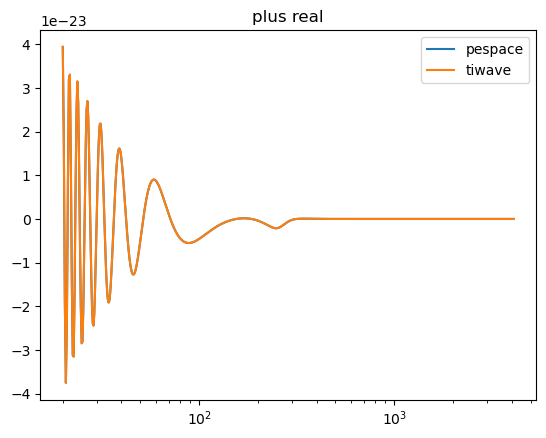

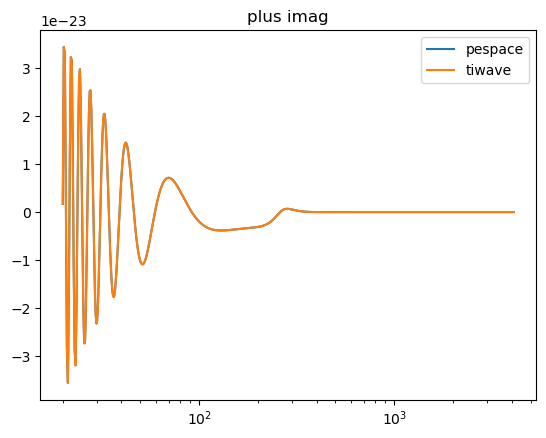

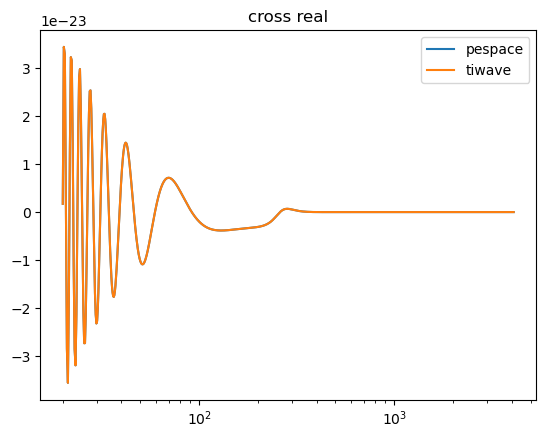

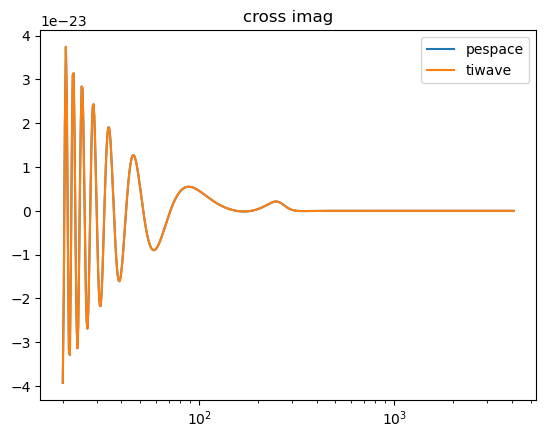

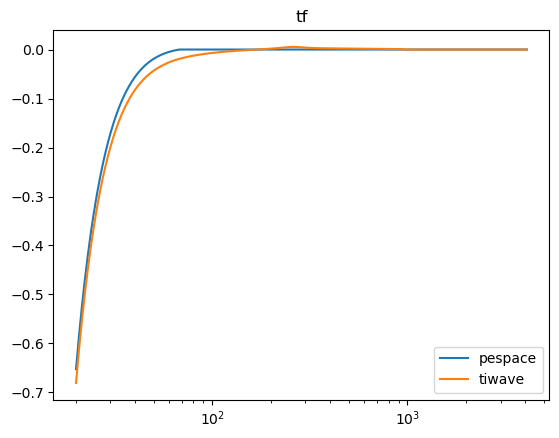

In [8]:
arr_pes = wf_pespace_FD.waveform_container.to_numpy()
arr_tiw = wf_tiwave.waveform_container.to_numpy()

plt.figure()
plt.title('plus real')
plt.semilogx(wf_pespace_FD._frequency_samples, arr_pes['plus'][:,0], label="pespace")
plt.semilogx(wf_pespace_FD._frequency_samples, arr_tiw['plus'][:,0], label='tiwave')
plt.legend()

plt.figure()
plt.title('plus imag')
plt.semilogx(wf_pespace_FD._frequency_samples, arr_pes['plus'][:,1], label="pespace")
plt.semilogx(wf_pespace_FD._frequency_samples, arr_tiw['plus'][:,1], label='tiwave')
plt.legend()

plt.figure()
plt.title('cross real')
plt.semilogx(wf_pespace_FD._frequency_samples, arr_pes['cross'][:,0], label="pespace")
plt.semilogx(wf_pespace_FD._frequency_samples, arr_tiw['cross'][:,0], label='tiwave')
plt.legend()

plt.figure()
plt.title('cross imag')
plt.semilogx(wf_pespace_FD._frequency_samples, arr_pes['cross'][:,1], label="pespace")
plt.semilogx(wf_pespace_FD._frequency_samples, arr_tiw['cross'][:,1], label='tiwave')
plt.legend()

plt.figure()
plt.title('tf')
plt.semilogx(wf_pespace_FD._frequency_samples, arr_pes['tf'], label="pespace")
plt.semilogx(wf_pespace_FD._frequency_samples, arr_tiw['tf'], label='tiwave')
plt.legend()

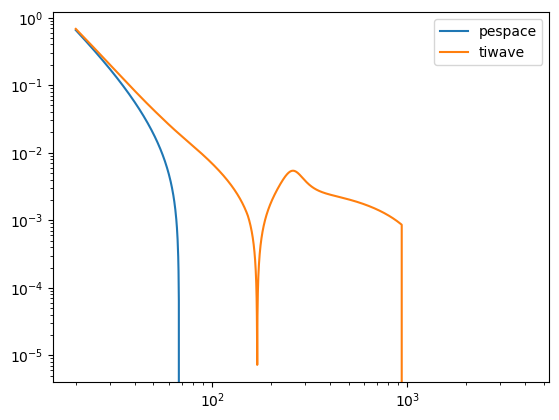

In [9]:
plt.figure()
plt.loglog(wf_pespace_FD._frequency_samples, np.abs(arr_pes['tf']), label='pespace')
plt.loglog(wf_pespace_FD._frequency_samples, np.abs(arr_tiw['tf']), label='tiwave')
plt.legend()